Safe Login Result: 1
SQL Injection Attack Result: 0


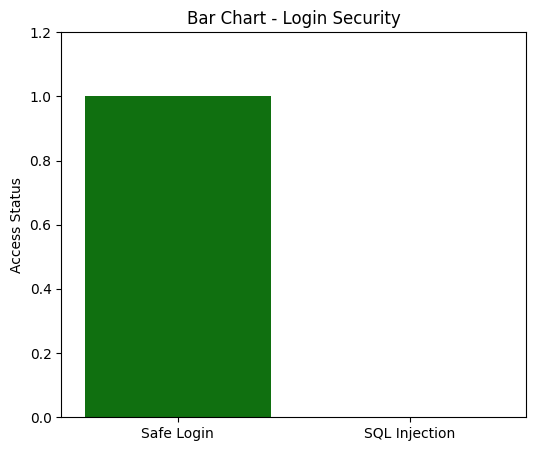

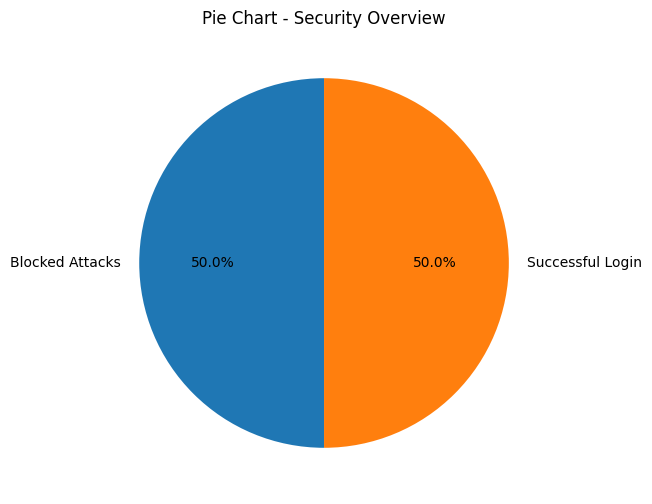

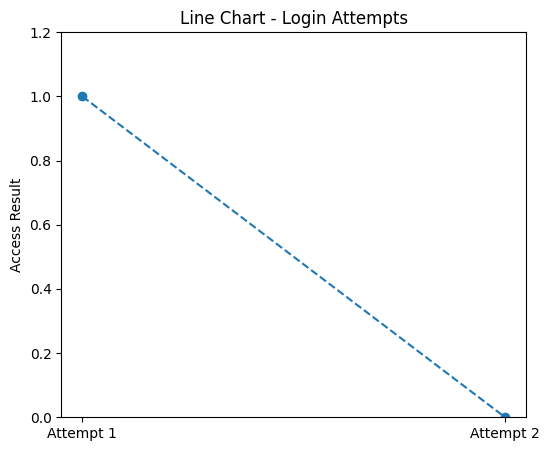

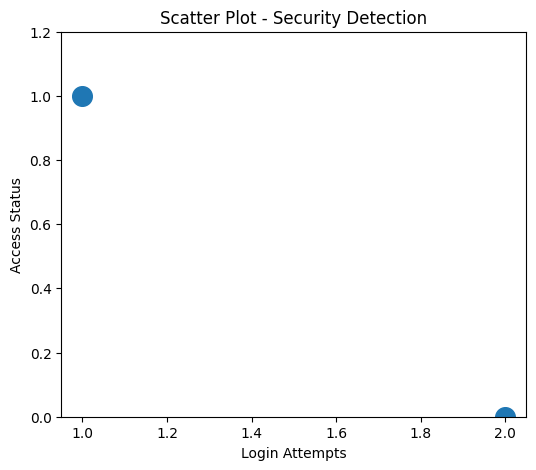


Security Report Saved Successfully!

Generated Report:


,Login Type,Result
0,Safe Login,Allowed
1,SQL Injection,Blocked


In [1]:
# ==========================================
# CodeAlpha Task 2
# SQL Injection Detection System with Graphs
# ==========================================

# Install required libraries (Colab usually has them)
!pip install pandas matplotlib seaborn -q

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Create Database
# ==========================================

conn = sqlite3.connect("users.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    username TEXT,
    password TEXT
)
""")

# Clear old data (optional)
cursor.execute("DELETE FROM users")

# Insert sample users
users = [
    ("admin", "admin123"),
    ("user1", "pass123"),
    ("user2", "pass456")
]

cursor.executemany(
    "INSERT INTO users (username, password) VALUES (?, ?)",
    users
)

conn.commit()

# ==========================================
# Secure Login Function
# ==========================================

def secure_login(username, password):

    query = "SELECT * FROM users WHERE username=? AND password=?"

    cursor.execute(query, (username, password))

    result = cursor.fetchone()

    if result:
        return 1
    else:
        return 0

# ==========================================
# Test Cases
# ==========================================

safe_login = secure_login("admin", "admin123")

sql_attack = secure_login("' OR '1'='1", "' OR '1'='1")

print("Safe Login Result:", safe_login)
print("SQL Injection Attack Result:", sql_attack)

# ==========================================
# Data for Graphs
# ==========================================

labels = ['Safe Login', 'SQL Injection']
values = [safe_login, sql_attack]

# ==========================================
# GRAPH 1 - BAR CHART
# ==========================================

plt.figure(figsize=(6,5))

sns.barplot(
    x=labels,
    y=values,
    hue=labels,
    palette=['green', 'red'],
    legend=False
)

plt.title("Bar Chart - Login Security")
plt.ylabel("Access Status")
plt.ylim(0,1.2)
plt.show()

# ==========================================
# GRAPH 2 - PIE CHART
# ==========================================

plt.figure(figsize=(6,6))

sizes = [1, 1]
pie_labels = ['Blocked Attacks', 'Successful Login']

plt.pie(
    sizes,
    labels=pie_labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Pie Chart - Security Overview")
plt.show()

# ==========================================
# GRAPH 3 - LINE CHART
# ==========================================

plt.figure(figsize=(6,5))

x = ['Attempt 1', 'Attempt 2']
y = [safe_login, sql_attack]

plt.plot(
    x,
    y,
    marker='o',
    linestyle='--'
)

plt.title("Line Chart - Login Attempts")
plt.ylabel("Access Result")
plt.ylim(0,1.2)
plt.show()

# ==========================================
# GRAPH 4 - SCATTER PLOT
# ==========================================

plt.figure(figsize=(6,5))

plt.scatter(
    [1,2],
    [safe_login, sql_attack],
    s=200
)

plt.title("Scatter Plot - Security Detection")
plt.xlabel("Login Attempts")
plt.ylabel("Access Status")
plt.ylim(0,1.2)
plt.show()

# ==========================================
# Save Security Report
# ==========================================

report = pd.DataFrame({
    'Login Type': labels,
    'Result': ['Allowed', 'Blocked']
})

report.to_csv("security_report.csv", index=False)

print("\nSecurity Report Saved Successfully!")

# Display report
print("\nGenerated Report:")
display(report)